In [5]:
from __future__ import print_function

import json
import numpy as np


config = json.load(open("input.json"))

aa_pdb_file = config["aa_pdb"]
cg_pdb_file = config["cg_pdb"]

In [6]:
with open("input.json") as f:
    text = f.read()

print(text)

{
    "aa_pdb" : "2CV5.pdb",
    "cg_pdb" : "histone_cg.pdb",
    "native_cutoff" : 8.0
}


In [7]:
import os

print("Current directory:")
print(os.getcwd())

print("\nAbsolute path:")
print(os.path.abspath("input.json"))

print("\nFiles in current directory:")
print(os.listdir())

Current directory:
/home/feynman/projects/codes/DNA_HISTONE_MODEL/SOP_nuclosome

Absolute path:
/home/feynman/projects/codes/DNA_HISTONE_MODEL/SOP_nuclosome/input.json

Files in current directory:
['AA2CG.py', 'notebook.ipynb', 'input.json']


In [8]:
import os

print(os.path.getsize("input.json"))

89


In [9]:
config = json.load(open("input.json"))

aa_pdb_file = config["aa_pdb"]
cg_pdb_file = config["cg_pdb"]

print(aa_pdb_file)
print(cg_pdb_file)

2CV5.pdb
histone_cg.pdb


In [15]:
with open(aa_pdb_file) as f:

    for line in f:

        record = line[:6].strip()

        if record != "ATOM":
            continue

        print(line[:60])
        

ATOM      1  O5'  DA I   1       3.706  52.204  -9.226  1.00
ATOM      2  C5'  DA I   1       3.099  52.854  -8.109  1.00
ATOM      3  C4'  DA I   1       1.672  52.401  -7.907  1.00
ATOM      4  O4'  DA I   1       1.666  50.958  -7.805  1.00
ATOM      5  C3'  DA I   1       1.073  52.896  -6.593  1.00
ATOM      6  O3'  DA I   1      -0.353  53.001  -6.697  1.00
ATOM      7  C2'  DA I   1       1.477  51.815  -5.610  1.00
ATOM      8  C1'  DA I   1       1.397  50.561  -6.465  1.00
ATOM      9  N9   DA I   1       2.341  49.503  -6.106  1.00
ATOM     10  C8   DA I   1       3.674  49.602  -5.781  1.00
ATOM     11  N7   DA I   1       4.235  48.449  -5.499  1.00
ATOM     12  C5   DA I   1       3.205  47.531  -5.652  1.00
ATOM     13  C6   DA I   1       3.145  46.136  -5.499  1.00
ATOM     14  N6   DA I   1       4.186  45.378  -5.144  1.00
ATOM     15  N1   DA I   1       1.960  45.533  -5.729  1.00
ATOM     16  C2   DA I   1       0.914  46.282  -6.086  1.00
ATOM     17  N3   DA I  

In [17]:
with open(aa_pdb_file) as f:

    for line in f:

        record = line[:6].strip()

        if record != "ATOM":
            continue

        # print(line[:60])
        print(line)

        print("Record =", line[:6])
        print("Atom   =", line[12:16])
        print("Resid  =", line[17:20])
        print("Chain  =", line[21])
        print("ResID  =", line[22:26])

ATOM      1  O5'  DA I   1       3.706  52.204  -9.226  1.00130.93           O  

Record = ATOM  
Atom   =  O5'
Resid  =  DA
Chain  = I
ResID  =    1
ATOM      2  C5'  DA I   1       3.099  52.854  -8.109  1.00131.12           C  

Record = ATOM  
Atom   =  C5'
Resid  =  DA
Chain  = I
ResID  =    1
ATOM      3  C4'  DA I   1       1.672  52.401  -7.907  1.00131.35           C  

Record = ATOM  
Atom   =  C4'
Resid  =  DA
Chain  = I
ResID  =    1
ATOM      4  O4'  DA I   1       1.666  50.958  -7.805  1.00131.99           O  

Record = ATOM  
Atom   =  O4'
Resid  =  DA
Chain  = I
ResID  =    1
ATOM      5  C3'  DA I   1       1.073  52.896  -6.593  1.00131.63           C  

Record = ATOM  
Atom   =  C3'
Resid  =  DA
Chain  = I
ResID  =    1
ATOM      6  O3'  DA I   1      -0.353  53.001  -6.697  1.00131.55           O  

Record = ATOM  
Atom   =  O3'
Resid  =  DA
Chain  = I
ResID  =    1
ATOM      7  C2'  DA I   1       1.477  51.815  -5.610  1.00131.99           C  

Record = ATOM  
At

In [18]:
histone_chains = ["A","B","C","D","E","F","G","H"]

chain_counts = {}

In [25]:
with open(aa_pdb_file) as f:

    for line in f:

        atom_name = line[12:16].strip()
        chain = line[21]

        if atom_name != "CA" or chain not in histone_chains:
            continue

        chain_id = line[21]

        if chain_id in histone_chains:
            if chain_id not in chain_counts:
                chain_counts[chain_id] = 0
            chain_counts[chain_id] += 1

In [26]:
print(chain_counts)

{'D': 2466, 'A': 2707, 'H': 2377, 'E': 2793, 'F': 2278, 'G': 2699, 'C': 2796, 'B': 2016}


In [27]:
with open(aa_pdb_file) as f:

    for line in f:

        atom_name = line[12:16].strip()
        chain = line[21]

        if chain not in histone_chains:
            continue

        if atom_name != "CA":
            continue

        if chain not in chain_counts:
            chain_counts[chain] = 0

        chain_counts[chain] += 1

In [28]:
print(chain_counts)
print("Total beads =", sum(chain_counts.values()))

{'D': 2562, 'A': 2804, 'H': 2471, 'E': 2892, 'F': 2363, 'G': 2803, 'C': 2904, 'B': 2094}
Total beads = 20893


In [29]:
count = 0

with open(aa_pdb_file) as f:

    for line in f:

        atom_name = line[12:16].strip()
        chain = line[21]

        if chain not in histone_chains:
            continue

        if atom_name != "CA":
            continue

        print(line)

        count += 1

        if count == 10:
            break

ATOM   5984  CA  PRO A  38      63.780  28.702  15.599  1.00 60.31           C  

ATOM   5991  CA  HIS A  39      61.284  26.696  17.699  1.00 58.36           C  

ATOM   6001  CA  ARG A  40      57.811  28.211  17.864  1.00 51.96           C  

ATOM   6012  CA  TYR A  41      54.705  26.440  19.209  1.00 42.95           C  

ATOM   6024  CA  ARG A  42      51.518  26.620  17.162  1.00 40.73           C  

ATOM   6035  CA  PRO A  43      48.742  29.009  18.292  1.00 39.11           C  

ATOM   6042  CA  GLY A  44      46.552  27.217  20.823  1.00 35.20           C  

ATOM   6046  CA  THR A  45      49.107  24.690  21.991  1.00 29.43           C  

ATOM   6053  CA  VAL A  46      50.431  27.128  24.593  1.00 30.01           C  

ATOM   6060  CA  ALA A  47      46.955  28.319  25.580  1.00 30.70           C  



In [30]:
print(aa_pdb_file)

2CV5.pdb


In [31]:
print(repr(line))

'ATOM   6060  CA  ALA A  47      46.955  28.319  25.580  1.00 30.70           C  \n'


In [32]:
ca_count = 0

with open(aa_pdb_file) as f:

    for line in f:

        if line[:4] != "ATOM":
            continue

        atom_name = line[12:16].strip()

        if atom_name == "CA":
            ca_count += 1

print(ca_count)

761


In [34]:
beads = []
with open(aa_pdb_file) as f:

    for line in f:

        # Step 1
        if line[:4] != "ATOM":
            continue

        # Step 2
        atom_name = line[12:16].strip()
        chain = line[21]

        # Step 3
        if chain not in histone_chains:
            continue

        # Step 4
        if atom_name != "CA":
            continue

        # This is a valid SOP bead
        resname = line[17:20].strip()
        resid = int(line[22:26])

        x = float(line[30:38])
        y = float(line[38:46])
        z = float(line[46:54])

        beads.append(
        {
            "chain": chain,
            "resid": resid,
            "resname": resname,
            "x": x,
            "y": y,
            "z": z
        }
        )

In [35]:
print("Total beads =", len(beads))

print(beads[0])
print(beads[1])
print(beads[2])

Total beads = 761
{'chain': 'A', 'resid': 38, 'resname': 'PRO', 'x': 63.78, 'y': 28.702, 'z': 15.599}
{'chain': 'A', 'resid': 39, 'resname': 'HIS', 'x': 61.284, 'y': 26.696, 'z': 17.699}
{'chain': 'A', 'resid': 40, 'resname': 'ARG', 'x': 57.811, 'y': 28.211, 'z': 17.864}


In [36]:
print(beads[-1])

{'chain': 'H', 'resid': 121, 'resname': 'ALA', 'x': 21.849, 'y': 3.618, 'z': 77.586}


In [37]:
print(beads[0]["chain"])
print(beads[-1]["chain"])

A
H


In [38]:
for i, bead in enumerate(beads[:5]):

    serial = i + 1

    print(
        serial,
        bead["resname"],
        bead["chain"],
        bead["resid"]
    )

1 PRO A 38
2 HIS A 39
3 ARG A 40
4 TYR A 41
5 ARG A 42


In [40]:
bead1 = beads[0]
bead2 = beads[10]

print(bead1)
print(bead2)

{'chain': 'A', 'resid': 38, 'resname': 'PRO', 'x': 63.78, 'y': 28.702, 'z': 15.599}
{'chain': 'A', 'resid': 48, 'resname': 'LEU', 'x': 46.038, 'y': 24.67, 'z': 26.185}


In [41]:
x1, y1, z1 = bead1["x"], bead1["y"], bead1["z"]
x2, y2, z2 = bead2["x"], bead2["y"], bead2["z"]

import numpy as np

r = np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)
print(r)

21.0499164843949


In [48]:
native_contacts = []
for i in range(len(beads)):
    for j in range(i+1, len(beads)):

        bead_i = beads[i]
        bead_j = beads[j]

        if bead_i["chain"] == bead_j["chain"]:
            if abs(bead_i["resid"] - bead_j["resid"]) <= 2:
                continue

        x1, y1, z1 = bead_i["x"], bead_i["y"], bead_i["z"]
        x2, y2, z2 = bead_j["x"], bead_j["y"], bead_j["z"]

        r_i = np.array([x1, y1, z1])
        r_j = np.array([x2, y2, z2])

        r_ij = np.linalg.norm(r_j - r_i)

        if r_ij < 8.0:
            native_contacts.append((i, j, r_ij))
print(f"Found {len(native_contacts)} native contacts:")
for contact in native_contacts[:10]:
    print(contact)

Found 2275 native contacts:
(3, 7, np.float64(6.491504294075448))
(3, 8, np.float64(6.9085364586140825))
(4, 7, np.float64(5.732107989213045))
(4, 8, np.float64(7.52724345295142))
(5, 8, np.float64(6.78921814349782))
(5, 9, np.float64(7.535543311533678))
(6, 9, np.float64(4.899577736907537))
(6, 10, np.float64(5.95839315587684))
(6, 116, np.float64(6.790190424428462))
(6, 117, np.float64(7.476701077346879))


In [43]:
print(beads[3])
print(beads[7])

{'chain': 'A', 'resid': 41, 'resname': 'TYR', 'x': 54.705, 'y': 26.44, 'z': 19.209}
{'chain': 'A', 'resid': 45, 'resname': 'THR', 'x': 49.107, 'y': 24.69, 'z': 21.991}


In [49]:
same_chain = 0
different_chain = 0

for i, j, r in native_contacts:

    if beads[i]["chain"] == beads[j]["chain"]:
        same_chain += 1
    else:
        different_chain += 1

print("Same chain:", same_chain)
print("Different chain:", different_chain)

Same chain: 1544
Different chain: 731


### SOP SINGLE BEAD MODEL

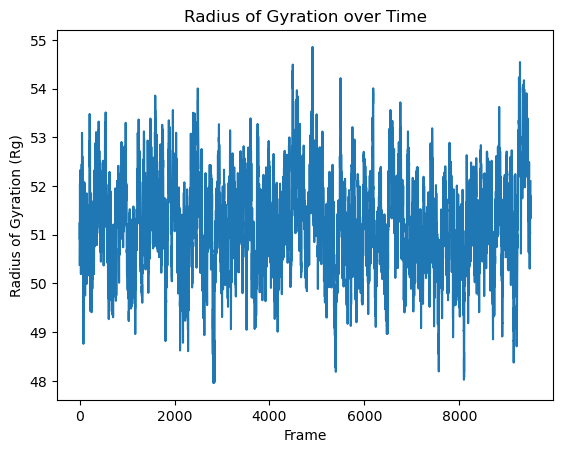

Average Rg =  51.21446527833553
Standard Deviation of Rg =  0.9510255684044495


In [3]:
# Rg calculation
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

u = mda.Universe("/data/cg_dna_histone/sop_single_bead/run1/hpc_final_converted.pdb",
                 "/data/cg_dna_histone/sop_single_bead/run1/hpc_traj.dcd")

rg = []

for ts in u.trajectory[1000:]:
    rg.append(u.atoms.radius_of_gyration())

rg = np.array(rg)
plt.plot(rg)
plt.xlabel("Frame")
plt.ylabel("Radius of Gyration (Rg)")
plt.title("Radius of Gyration over Time")
plt.show()

print("Average Rg = ", rg.mean())
print("Standard Deviation of Rg = ", rg.std())

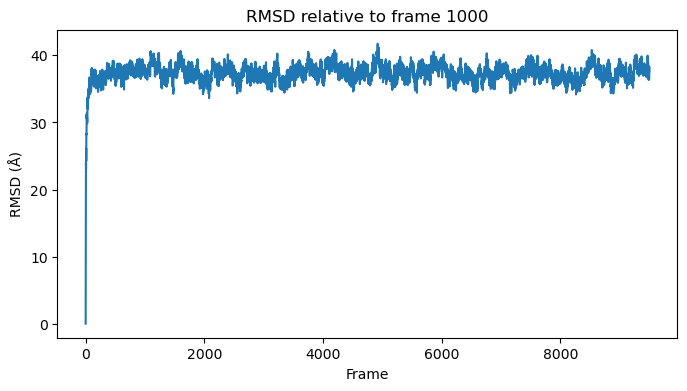

Average RMSD = 37.32955415540738
Std RMSD = 1.3341965771352307


In [8]:
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt

ref_frame = 1000

R = rms.RMSD(
    u,
    u,
    select="all",
    ref_frame=ref_frame
)

R.run()

rmsd = R.results.rmsd[:,2]

plt.figure(figsize=(8,4))
plt.plot(rmsd[ref_frame:])
plt.xlabel("Frame")
plt.ylabel("RMSD (Å)")
plt.title("RMSD relative to frame 1000")
plt.show()

print("Average RMSD =", rmsd[ref_frame:].mean())
print("Std RMSD =", rmsd[ref_frame:].std())

In [5]:
len(u.trajectory)

10500

In [9]:
print(u.residues)

<ResidueGroup [<Residue MET, 1>, <Residue ALA, 2>, <Residue ARG, 3>, ..., <Residue CL, 154>, <Residue CL, 155>, <Residue CL, 156>]>


In [10]:
for r in u.residues[:20]:
    print(r.resid, r.resname)

1 MET
2 ALA
3 ARG
4 THR
5 LYS
6 GLN
7 THR
8 ALA
9 ARG
10 LYS
11 SER
12 THR
13 GLY
14 GLY
15 LYS
16 ALA
17 PRO
18 ARG
19 LYS
20 GLN


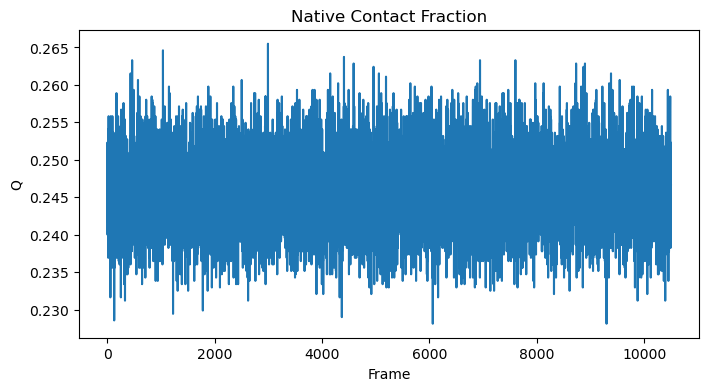

Average Q = 0.2460116797488226
Std Q = 0.00498905042955464


In [20]:
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

# ---------- load native contacts ----------
native_contacts = np.loadtxt("native_contacts.dat")

idx_i = native_contacts[:,0].astype(int) - 1
idx_j = native_contacts[:,1].astype(int) - 1
r0    = native_contacts[:,2]

# SOP native-contact criterion
cutoff_factor = 1.2

Q = []

for ts in u.trajectory:

    pos = u.atoms.positions

    rij = pos[idx_i] - pos[idx_j]
    dist = np.linalg.norm(rij, axis=1)

    formed = np.sum(dist < cutoff_factor * r0)

    Q.append(formed / len(r0))

Q = np.array(Q)

plt.figure(figsize=(8,4))
plt.plot(Q)
plt.xlabel("Frame")
plt.ylabel("Q")
plt.title("Native Contact Fraction")
plt.show()

print("Average Q =", Q.mean())
print("Std Q =", Q.std())

In [12]:
u.trajectory[0]

pos = u.atoms.positions

rij = pos[idx_i] - pos[idx_j]
dist = np.linalg.norm(rij, axis=1)

print(np.mean(dist < 1.2*r0))

0.24703296703296704


In [13]:
u.trajectory[-1]

pos = u.atoms.positions

rij = pos[idx_i] - pos[idx_j]
dist = np.linalg.norm(rij, axis=1)

print(np.mean(dist < 1.2*r0))

0.2465934065934066


In [14]:
print(len(idx_i))
print(idx_i.min(), idx_i.max())
print(idx_j.min(), idx_j.max())
print(len(u.atoms))

2275
2 756
6 759
1108


In [15]:
native_contacts = np.loadtxt("native_contacts.dat")

idx_i = native_contacts[:,0].astype(int)
idx_j = native_contacts[:,1].astype(int)

r0 = native_contacts[:,2]

In [16]:
u.trajectory[0]

pos = u.atoms.positions

rij = pos[idx_i] - pos[idx_j]
dist = np.linalg.norm(rij, axis=1)

print(np.mean(dist < 1.2*r0))

0.2562637362637363


In [17]:
u_native = mda.Universe("histone_cg.pdb")

/home/feynman/miniconda3/envs/venv/lib/python3.13/site-packages/MDAnalysis/topology/PDBParser.py:376: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


In [18]:
pos = u_native.atoms.positions

rij = pos[idx_i] - pos[idx_j]
dist = np.linalg.norm(rij, axis=1)

print(np.mean(dist < 1.2*r0))

1.0


In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# USER INPUT
# ============================================================

DCD_FILE = "/data/run9/dna_traj.dcd"
TOP_FILE = "/data/run9/dna_final.pdb"

# Number of initial frames used to estimate normal behavior
N_REFERENCE = 1000

# Blow-up threshold
SIGMA_CUTOFF = 5

# Histogram bins
NBINS = 100

# ============================================================
# FUNCTIONS
# ============================================================

def unwrap_chain(coords, box):

    unwrapped = np.copy(coords)

    for i in range(1, len(coords)):

        dr = unwrapped[i] - unwrapped[i - 1]

        dr -= box * np.round(dr / box)

        unwrapped[i] = unwrapped[i - 1] + dr

    return unwrapped


def compute_rg(coords):

    center = np.mean(coords, axis=0)

    rg2 = np.mean(
        np.sum((coords - center) ** 2, axis=1)
    )

    return np.sqrt(rg2)


# ============================================================
# LOAD TRAJECTORY AND CALCULATE RG
# ============================================================

print("Loading trajectory in chunks...")

rg_values = []

chunk_size = 500   # increase to 500 if memory allows

frame_counter = 0

for chunk in md.iterload(
        DCD_FILE,
        top=TOP_FILE,
        chunk=chunk_size,
        stop=150000):

    print(f"Processing frames {frame_counter} "
          f"to {frame_counter + chunk.n_frames}")

    for i in range(chunk.n_frames):

        xyz = chunk.xyz[i]

        box = chunk.unitcell_lengths[i]

        xyz_unwrapped = unwrap_chain(xyz, box)

        rg = compute_rg(xyz_unwrapped)

        rg_values.append(rg)

    frame_counter += chunk.n_frames

rg_values = np.array(rg_values)

print("Total frames analyzed:", len(rg_values))

# ============================================================
# SAVE FULL RG TRAJECTORY
# ============================================================

np.savetxt(
    "Rg_timeseries.dat",
    np.column_stack((np.arange(len(rg_values)), rg_values)),
    header="Frame Rg_nm"
)

# ============================================================
# DETECT BLOW-UP REGION
# ============================================================

reference = rg_values[:N_REFERENCE]

mean_rg = np.mean(reference)
std_rg = np.std(reference)

threshold = mean_rg + SIGMA_CUTOFF * std_rg

bad_frames = np.where(rg_values > threshold)[0]

if len(bad_frames) > 0:
    first_bad_frame = bad_frames[0]
else:
    first_bad_frame = len(rg_values)

rg_clean = rg_values[:first_bad_frame]

print()
print("===== ANALYSIS =====")
print(f"Mean (reference)      = {mean_rg:.4f} nm")
print(f"Std (reference)       = {std_rg:.4f} nm")
print(f"Threshold             = {threshold:.4f} nm")
print(f"Last accepted frame   = {first_bad_frame-1}")
print(f"Frames used           = {len(rg_clean)}")

# ============================================================
# SAVE CLEAN RG TRAJECTORY
# ============================================================

np.savetxt(
    "Rg_clean.dat",
    np.column_stack(
        (np.arange(len(rg_clean)), rg_clean)
    ),
    header="Frame Rg_nm"
)

# ============================================================
# RG DISTRIBUTION
# ============================================================

hist, edges = np.histogram(
    rg_clean,
    bins=NBINS,
    density=True
)

centers = 0.5 * (edges[1:] + edges[:-1])

np.savetxt(
    "Rg_distribution.dat",
    np.column_stack((centers, hist)),
    header="Rg_nm ProbabilityDensity"
)

# ============================================================
# PLOT RG VS FRAME
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(rg_values, lw=1)

if len(bad_frames) > 0:
    plt.axvline(
        first_bad_frame,
        color="red",
        ls="--",
        label="blow-up detected"
    )

plt.xlabel("Frame")
plt.ylabel(r"$R_g$ (nm)")
plt.legend()

plt.tight_layout()

plt.savefig(
    "Rg_vs_frame.png",
    dpi=300
)

# ============================================================
# PLOT DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 5))

plt.hist(
    rg_clean,
    bins=NBINS,
    density=True
)

plt.xlabel(r"$R_g$ (nm)")
plt.ylabel("Probability Density")

plt.tight_layout()

plt.savefig(
    "Rg_distribution.png",
    dpi=300
)

plt.show()

print("Done.")

Loading trajectory...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


MemoryError: Unable to allocate 78.1 GiB for an array with shape (230596, 30303, 3) and data type float32

In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUT FILES
# ============================================================

DCD_FILE = "/data/run9/dna_traj.dcd"
TOP_FILE = "/data/run9/dna_final.pdb"

CHUNK_SIZE = 5000

# ============================================================
# LOAD TOPOLOGY AND SELECT DNA ONLY
# ============================================================

print("Reading topology...")

first = md.load_frame(DCD_FILE, 0, top=TOP_FILE)

top = first.topology

# Exclude common ions
dna_atoms = top.select(
    "not resname NA and "
    "not resname CL and "
    "not resname K and "
    "not resname MG and "
    "not resname CA"
)

print("Total particles :", top.n_atoms)
print("DNA particles   :", len(dna_atoms))

# ============================================================
# COMPUTE Rg
# ============================================================

rg_values = []

print("Processing trajectory...")

for chunk_id, chunk in enumerate(
        md.iterload(
            DCD_FILE,
            top=TOP_FILE,
            chunk=CHUNK_SIZE
        )):

    print(f"Chunk {chunk_id}")

    dna_xyz = chunk.xyz[:, dna_atoms, :]

    # centroid of DNA for each frame
    center = dna_xyz.mean(axis=1, keepdims=True)

    # Rg calculation
    rg = np.sqrt(
        np.mean(
            np.sum(
                (dna_xyz - center) ** 2,
                axis=2
            ),
            axis=1
        )
    )

    rg_values.extend(rg)

rg_values = np.array(rg_values)

print("Finished.")
print("Frames analyzed:", len(rg_values))

# ============================================================
# SAVE TIMESERIES
# ============================================================

np.savetxt(
    "Rg_timeseries.dat",
    np.column_stack(
        (
            np.arange(len(rg_values)),
            rg_values
        )
    ),
    header="Frame Rg_nm"
)

# ============================================================
# PLOT Rg VS FRAME
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(rg_values, lw=1)

plt.xlabel("Frame")
plt.ylabel("Rg (nm)")
plt.title("DNA Radius of Gyration")

plt.tight_layout()
plt.savefig("Rg_vs_frame.png", dpi=300)

plt.show()

print("Saved:")
print("  Rg_timeseries.dat")
print("  Rg_vs_frame.png")


Reading topology...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Total particles : 30303
DNA particles   : 874
Processing trajectory...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Chunk 0
Chunk 1
Chunk 2
Chunk 3
Chunk 4
Chunk 5
Chunk 6
Chunk 7
Chunk 8
Chunk 9
Chunk 10
Chunk 11
Chunk 12
Chunk 13
Chunk 14
Chunk 15
Chunk 16
Chunk 17
Chunk 18
Chunk 19
Chunk 20
Chunk 21
Chunk 22
Chunk 23
Chunk 24
Chunk 25
Chunk 26
Chunk 27
Chunk 28
Chunk 29
Chunk 30
Chunk 31
Chunk 32
Chunk 33


Reading topology ...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Total particles = 30303
Selected DNA beads = 874
Processing trajectory ...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Processed 500 frames
Processed 1000 frames
Processed 1500 frames
Processed 2000 frames
Processed 2500 frames
Processed 3000 frames
Processed 3500 frames
Processed 4000 frames
Processed 4500 frames
Processed 5000 frames
Processed 5500 frames
Processed 6000 frames
Processed 6500 frames
Processed 7000 frames
Processed 7500 frames
Processed 8000 frames
Processed 8500 frames
Processed 9000 frames
Processed 9500 frames
Processed 10000 frames
Processed 10500 frames
Processed 11000 frames
Processed 11500 frames
Processed 12000 frames
Processed 12500 frames
Processed 13000 frames
Processed 13500 frames
Processed 14000 frames
Processed 14500 frames
Proce

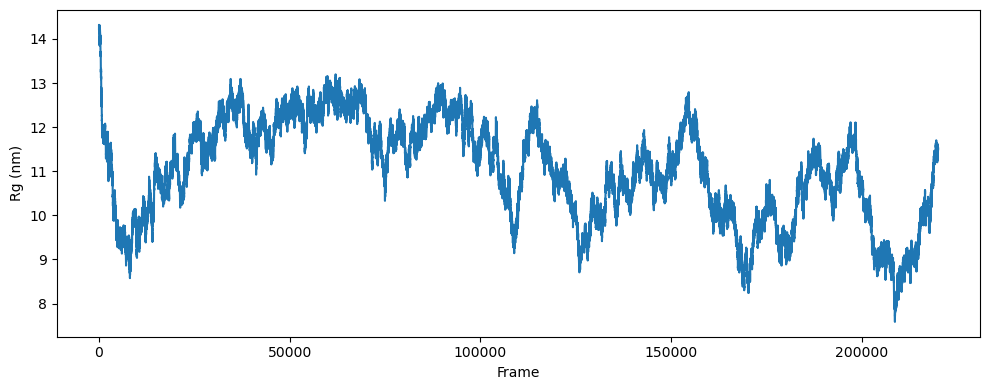

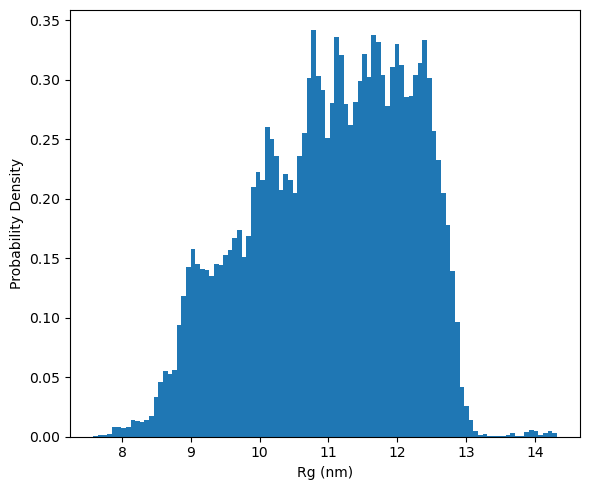


Files saved:
  Rg_timeseries.dat
  Rg_distribution.dat
  Rg_vs_frame.png
  Rg_distribution.png


In [1]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# USER INPUT
# ============================================================

DCD_FILE = "/data/run9/dna_traj.dcd"
TOP_FILE = "/data/run9/dna_final.pdb"
CHUNK_SIZE = 500

# Frame where the simulation starts blowing up
# You said the last ~10k frames are bad, so adjust as needed
LAST_GOOD_FRAME = 220000

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def unwrap_frame(coords, box):

    unwrapped = coords.copy()

    for i in range(1, len(coords)):

        delta = unwrapped[i] - unwrapped[i-1]

        delta -= box * np.round(delta / box)

        unwrapped[i] = unwrapped[i-1] + delta

    return unwrapped


def compute_rg(coords):

    center = coords.mean(axis=0)

    rg = np.sqrt(
        np.mean(
            np.sum(
                (coords - center)**2,
                axis=1
            )
        )
    )

    return rg

# ============================================================
# LOAD TOPOLOGY
# ============================================================

print("Reading topology ...")

first = md.load_frame(
    DCD_FILE,
    0,
    top=TOP_FILE
)

top = first.topology

# Exclude common ions

dna_atoms = top.select(
    "not resname NA and "
    "not resname CL and "
    "not resname K and "
    "not resname MG and "
    "not resname CA"
)

print("Total particles =", top.n_atoms)
print("Selected DNA beads =", len(dna_atoms))

# ============================================================
# PROCESS TRAJECTORY
# ============================================================

rg_values = []

frame_counter = 0

print("Processing trajectory ...")

for chunk in md.iterload(
        DCD_FILE,
        top=TOP_FILE,
        chunk=CHUNK_SIZE):

    for i in range(chunk.n_frames):

        if frame_counter >= LAST_GOOD_FRAME:
            break

        coords = chunk.xyz[i, dna_atoms, :]

        box = chunk.unitcell_lengths[i]

        coords_unwrapped = unwrap_frame(
            coords,
            box
        )

        rg = compute_rg(coords_unwrapped)

        rg_values.append(rg)

        frame_counter += 1

    if frame_counter >= LAST_GOOD_FRAME:
        break

    print(f"Processed {frame_counter} frames")

rg_values = np.array(rg_values)

print("Done")

# ============================================================
# STATISTICS
# ============================================================

print()
print("===== Rg Statistics =====")
print("Frames =", len(rg_values))
print("Mean   =", np.mean(rg_values))
print("Std    =", np.std(rg_values))
print("Min    =", np.min(rg_values))
print("Max    =", np.max(rg_values))

# ============================================================
# SAVE TIMESERIES
# ============================================================

np.savetxt(
    "Rg_timeseries.dat",
    np.column_stack(
        (
            np.arange(len(rg_values)),
            rg_values
        )
    ),
    header="Frame Rg_nm"
)

# ============================================================
# PLOT RG VS FRAME
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(rg_values)

plt.xlabel("Frame")
plt.ylabel("Rg (nm)")

plt.tight_layout()

plt.savefig(
    "Rg_vs_frame.png",
    dpi=300
)

plt.show()

# ============================================================
# Rg DISTRIBUTION
# ============================================================

hist, edges = np.histogram(
    rg_values,
    bins=100,
    density=True
)

centers = 0.5 * (
    edges[1:] + edges[:-1]
)

np.savetxt(
    "Rg_distribution.dat",
    np.column_stack(
        (
            centers,
            hist
        )
    ),
    header="Rg_nm ProbabilityDensity"
)

# ============================================================
# PLOT DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,5))

plt.hist(
    rg_values,
    bins=100,
    density=True
)

plt.xlabel("Rg (nm)")
plt.ylabel("Probability Density")

plt.tight_layout()

plt.savefig(
    "Rg_distribution.png",
    dpi=300
)

plt.show()

print()
print("Files saved:")
print("  Rg_timeseries.dat")
print("  Rg_distribution.dat")
print("  Rg_vs_frame.png")
print("  Rg_distribution.png")

In [2]:
import mdtraj as md

t = md.load_frame("/data/run9/dna_traj.dcd", 0, top="/data/run9/dna_final.pdb")

for atom in list(t.topology.atoms)[:30]:
    print(atom.index, atom.name, atom.residue.name)

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
0 S DA
1 B DA
2 P DT
3 S DT
4 B DT
5 P DC
6 S DC
7 B DC
8 P DA
9 S DA
10 B DA
11 P DA
12 S DA
13 B DA
14 P DT
15 S DT
16 B DT
17 P DA
18 S DA
19 B DA
20 P DT
21 S DT
22 B DT
23 P DC
24 S DC
25 B DC
26 P DC
27 S DC
28 B DC
29 P DA


Reading topology...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
DNA beads = 874
Total DNA mass = 94449.58796
Processing trajectory...
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Processed 200000 frames
Done.
Mean = 10.973574009814392
Std  = 0.8389868248785062
Min  = 8.239900076985029
Max  = 12.796603061509852


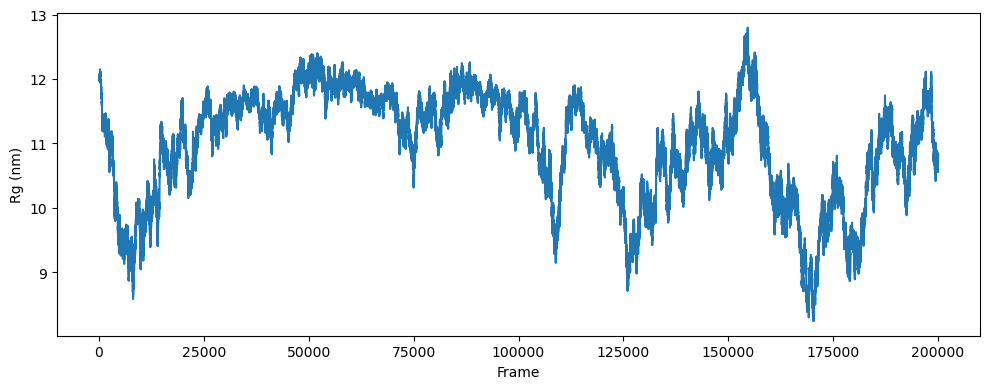

AttributeError: Rectangle.set() got an unexpected keyword argument 'edgecolour'

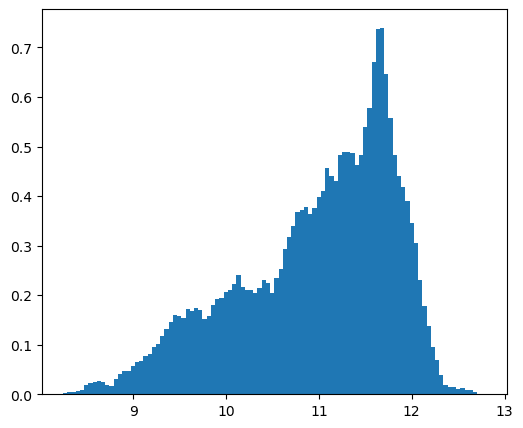

In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# INPUT
# =====================================================

DCD_FILE = "/data/run9/dna_traj.dcd"
TOP_FILE = "/data/run9/dna_final.pdb"

CHUNK_SIZE = 1000

# remove blown-up region
LAST_GOOD_FRAME = 200000

# =====================================================
# MASS DEFINITIONS
# =====================================================

P_MASS = 62.9714
S_MASS = 131.1083

BASE_MASS = {
    "DA": 134.11876,   # Adenine
    "DT": 125.10794,   # Thymine
    "DG": 150.11816,   # Guanine
    "DC": 110.09406    # Cytosine
}

# =====================================================
# LOAD TOPOLOGY
# =====================================================

print("Reading topology...")

first = md.load_frame(
    DCD_FILE,
    0,
    top=TOP_FILE
)

top = first.topology

# keep only DNA beads

dna_atoms = top.select(
    "not resname NA and "
    "not resname CL and "
    "not resname MG and "
    "not resname K and "
    "not resname CA"
)

print("DNA beads =", len(dna_atoms))

# =====================================================
# BUILD MASS ARRAY
# =====================================================

masses = []

for idx in dna_atoms:

    atom = list(top.atoms)[idx]

    bead_name = atom.name.strip()
    res_name = atom.residue.name.strip()

    if bead_name == "P":
        masses.append(P_MASS)

    elif bead_name == "S":
        masses.append(S_MASS)

    elif bead_name == "B":
        masses.append(BASE_MASS[res_name])

    else:
        raise ValueError(
            f"Unknown bead: {bead_name}"
        )

masses = np.array(masses)

M = np.sum(masses)

print("Total DNA mass =", M)

# =====================================================
# Rg FUNCTION
# =====================================================

def rg_pairwise_pbc(coords, box, masses):

    N = coords.shape[0]

    dx = coords[:, None, 0] - coords[None, :, 0]
    dy = coords[:, None, 1] - coords[None, :, 1]
    dz = coords[:, None, 2] - coords[None, :, 2]

    # minimum image convention

    dx -= box[0] * np.round(dx / box[0])
    dy -= box[1] * np.round(dy / box[1])
    dz -= box[2] * np.round(dz / box[2])

    rij2 = dx*dx + dy*dy + dz*dz

    mass_matrix = masses[:, None] * masses[None, :]

    rg2 = np.sum(
        mass_matrix * rij2
    ) / (2.0 * M * M)

    return np.sqrt(rg2)

# =====================================================
# MAIN LOOP
# =====================================================

rg_values = []

frame_counter = 0

print("Processing trajectory...")

for chunk in md.iterload(
        DCD_FILE,
        top=TOP_FILE,
        chunk=CHUNK_SIZE):

    for i in range(chunk.n_frames):

        if frame_counter >= LAST_GOOD_FRAME:
            break

        coords = chunk.xyz[i, dna_atoms, :]
        box = chunk.unitcell_lengths[i]

        rg = rg_pairwise_pbc(
            coords,
            box,
            masses
        )

        rg_values.append(rg)

        frame_counter += 1

    print(
        f"Processed {frame_counter} frames",
        end="\r"
    )

    if frame_counter >= LAST_GOOD_FRAME:
        break

rg_values = np.array(rg_values)

print("\nDone.")

# =====================================================
# STATS
# =====================================================

print("Mean =", np.mean(rg_values))
print("Std  =", np.std(rg_values))
print("Min  =", np.min(rg_values))
print("Max  =", np.max(rg_values))

# =====================================================
# SAVE TIMESERIES
# =====================================================

np.savetxt(
    "Rg_timeseries_pairwise.dat",
    np.column_stack(
        (
            np.arange(len(rg_values)),
            rg_values
        )
    ),
    header="Frame Rg_nm"
)

# =====================================================
# PLOT Rg
# =====================================================

plt.figure(figsize=(10,4))

plt.plot(rg_values)

plt.xlabel("Frame")
plt.ylabel("Rg (nm)")

plt.tight_layout()

plt.savefig(
    "Rg_vs_frame_pairwise.png",
    dpi=300
)

plt.show()

# =====================================================
# DISTRIBUTION
# =====================================================

hist, edges = np.histogram(
    rg_values,
    bins=100,
    density=True
)

centers = 0.5 * (
    edges[1:] + edges[:-1]
)

np.savetxt(
    "Rg_distribution_pairwise.dat",
    np.column_stack(
        (
            centers,
            hist
        )
    ),
    header="Rg_nm ProbabilityDensity"
)

plt.figure(figsize=(6,5))

plt.hist(
    rg_values,
    bins=100,
    density=True
)

plt.xlabel("Rg (nm)")
plt.ylabel("Probability Density")

plt.tight_layout()

plt.savefig(
    "Rg_distribution_pairwise.png",
    dpi=300
)

plt.show()

In [6]:
hist, edges = np.histogram(
    rg_values,
    bins=100,
    density=True
)

bin_width = edges[1] - edges[0]

print(np.sum(hist * bin_width))

0.9999999999999817
